In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
df=pd.read_csv("/content/sample_data/store_customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


In [ ]:
df.shape

(1000, 5)

In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


In [ ]:
print(df.isnull().sum())

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64


In [ ]:
numeric_columns = [
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [ ]:
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [ ]:
features = [
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]

X = df[features]

In [ ]:
X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,39.0,59.9,58.0
1,34.0,48.4,37.0
2,40.0,70.5,26.0
3,47.0,81.1,30.0
4,33.0,42.1,58.0


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[ 0.0061401 ,  0.09745644,  0.76510194],
       [-0.36825649, -0.3051838 , -0.28311966],
       [ 0.08101942,  0.46858571, -0.83218813],
       [ 0.60517466,  0.83971497, -0.63252687],
       [-0.44313581, -0.52576062,  0.76510194]])

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [ ]:
print(pca.explained_variance_ratio_)

[0.91000949 0.06324881 0.02674169]


In [ ]:
print(pca.explained_variance_ratio_.cumsum())

[0.91000949 0.97325831 1.        ]


In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [ ]:
X_pca.shape

(1000, 2)

In [ ]:
print(X_pca[:5])

[[-0.3716141   0.66930681]
 [-0.23299693 -0.50406887]
 [ 0.7910725  -0.47860401]
 [ 1.20057987  0.04793744]
 [-0.99758016  0.24665504]]


K Means

In [ ]:
wcss=[]

In [ ]:
for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_pca)

    wcss.append(kmeans.inertia_)

In [ ]:
print(wcss)

[2919.774918379618, 964.2093871757844, 551.484510891302, 394.570423982607, 330.50617041513647, 279.515687622463, 231.95162910402502, 195.22935627101236, 173.69844089063935, 158.73359944260034]


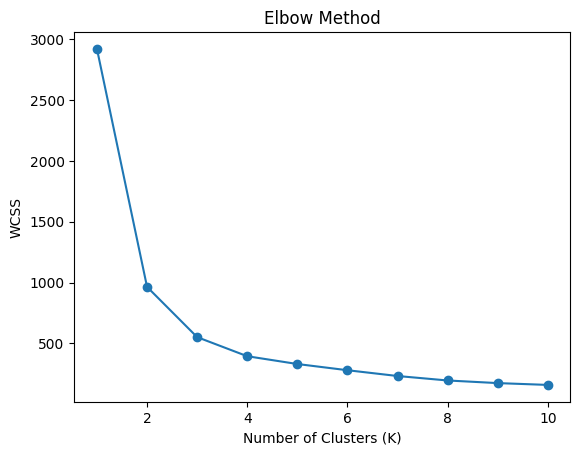

In [ ]:
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [ ]:
silhouette_scores = []

In [ ]:
for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca)

    score = silhouette_score(X_pca, labels)

    silhouette_scores.append(score)

In [ ]:
silhouette_scores

[np.float64(0.5869234187966567),
 np.float64(0.49978540571502117),
 np.float64(0.4057452876454236),
 np.float64(0.3615155688679362),
 np.float64(0.35936694079369463),
 np.float64(0.3622864616914368),
 np.float64(0.37190196457116487),
 np.float64(0.36652690292017914),
 np.float64(0.36070858870427847)]

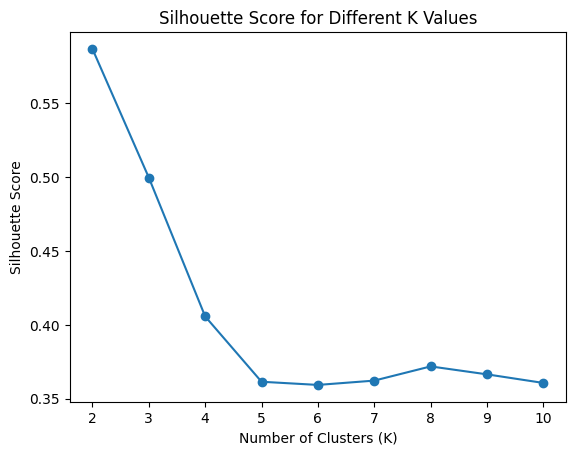

In [ ]:
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')
plt.show()

In [ ]:
final_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

In [ ]:
cluster_labels = final_kmeans.fit_predict(X_pca)

In [ ]:
print(cluster_labels[:10])

[0 0 1 1 0 0 1 1 0 0]


In [ ]:
print(np.bincount(cluster_labels))

[703 297]


In [ ]:
print(final_kmeans.cluster_centers_)

[[-0.90892471  0.00579905]
 [ 2.15142785 -0.01372637]]


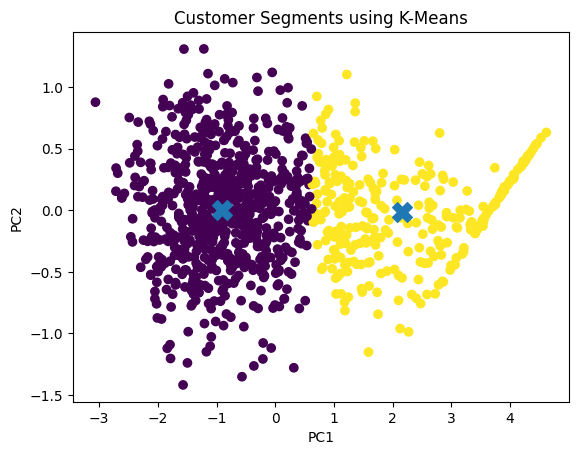

In [ ]:
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels
)

plt.scatter(
    final_kmeans.cluster_centers_[:, 0],
    final_kmeans.cluster_centers_[:, 1],
    marker='X',
    s=200
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Segments using K-Means')
plt.show()

In [ ]:
df['Cluster'] = cluster_labels

In [ ]:
df['Segment'] = df['Cluster'].map({
    0: 'Young Active Spenders',
    1: 'Affluent Low-Spending Customers'
})

In [ ]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Segment
0,1000,M,39.0,59.9,58.0,0,Young Active Spenders
1,1001,M,34.0,48.4,37.0,0,Young Active Spenders
2,1002,F,40.0,70.5,26.0,1,Affluent Low-Spending Customers
3,1003,F,47.0,81.1,30.0,1,Affluent Low-Spending Customers
4,1004,F,33.0,42.1,58.0,0,Young Active Spenders
...,...,...,...,...,...,...,...
995,1995,M,80.0,133.3,1.0,1,Affluent Low-Spending Customers
996,1996,M,44.0,82.6,40.0,1,Affluent Low-Spending Customers
997,1997,F,46.0,67.7,26.0,1,Affluent Low-Spending Customers
998,1998,F,28.0,45.7,59.0,0,Young Active Spenders


In [ ]:
cluster_profile = df.groupby(['Cluster','Segment'])[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean().reset_index()

print(cluster_profile)

   Cluster                          Segment        Age  Annual Income (k$)  \
0        0            Young Active Spenders  32.113798           41.480085   
1        1  Affluent Low-Spending Customers  55.023569           94.127946   

   Spending Score (1-100)  
0               53.034139  
1               18.144781  


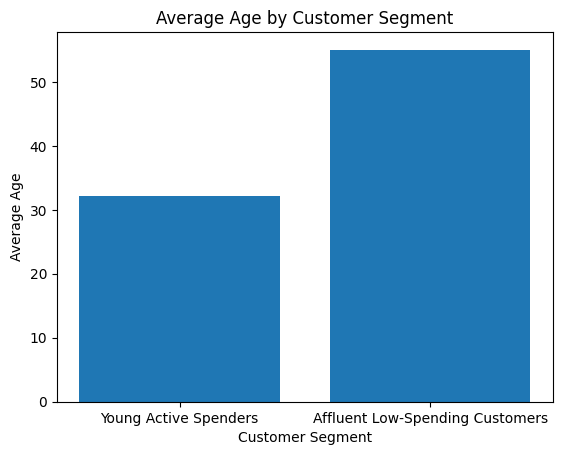

In [ ]:
plt.bar(
    cluster_profile['Segment'],
    cluster_profile['Age']
)

plt.xlabel('Customer Segment')
plt.ylabel('Average Age')
plt.title('Average Age by Customer Segment')

plt.show()

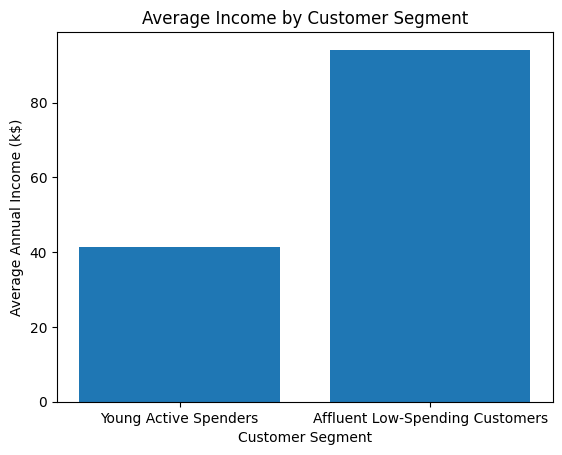

In [ ]:
plt.bar(
    cluster_profile['Segment'],
    cluster_profile['Annual Income (k$)']
)

plt.xlabel('Customer Segment')
plt.ylabel('Average Annual Income (k$)')
plt.title('Average Income by Customer Segment')

plt.show()

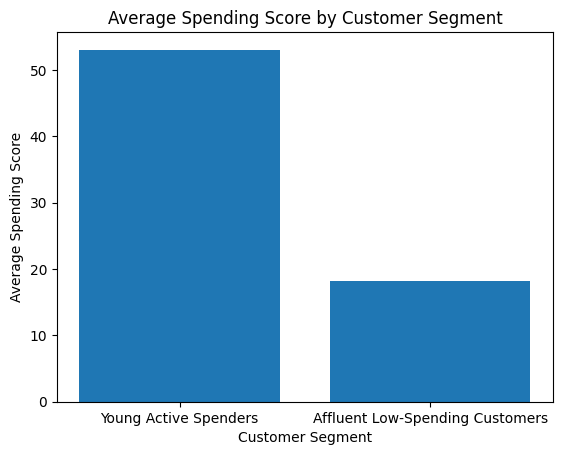

In [ ]:
plt.bar(
    cluster_profile['Segment'],
    cluster_profile['Spending Score (1-100)']
)

plt.xlabel('Customer Segment')
plt.ylabel('Average Spending Score')
plt.title('Average Spending Score by Customer Segment')

plt.show()

Hierarchical Clustering model

In [ ]:
hierarchical = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

In [ ]:
hierarchical_labels = hierarchical.fit_predict(X_pca)

In [ ]:
Z = linkage(X_pca, method='ward')

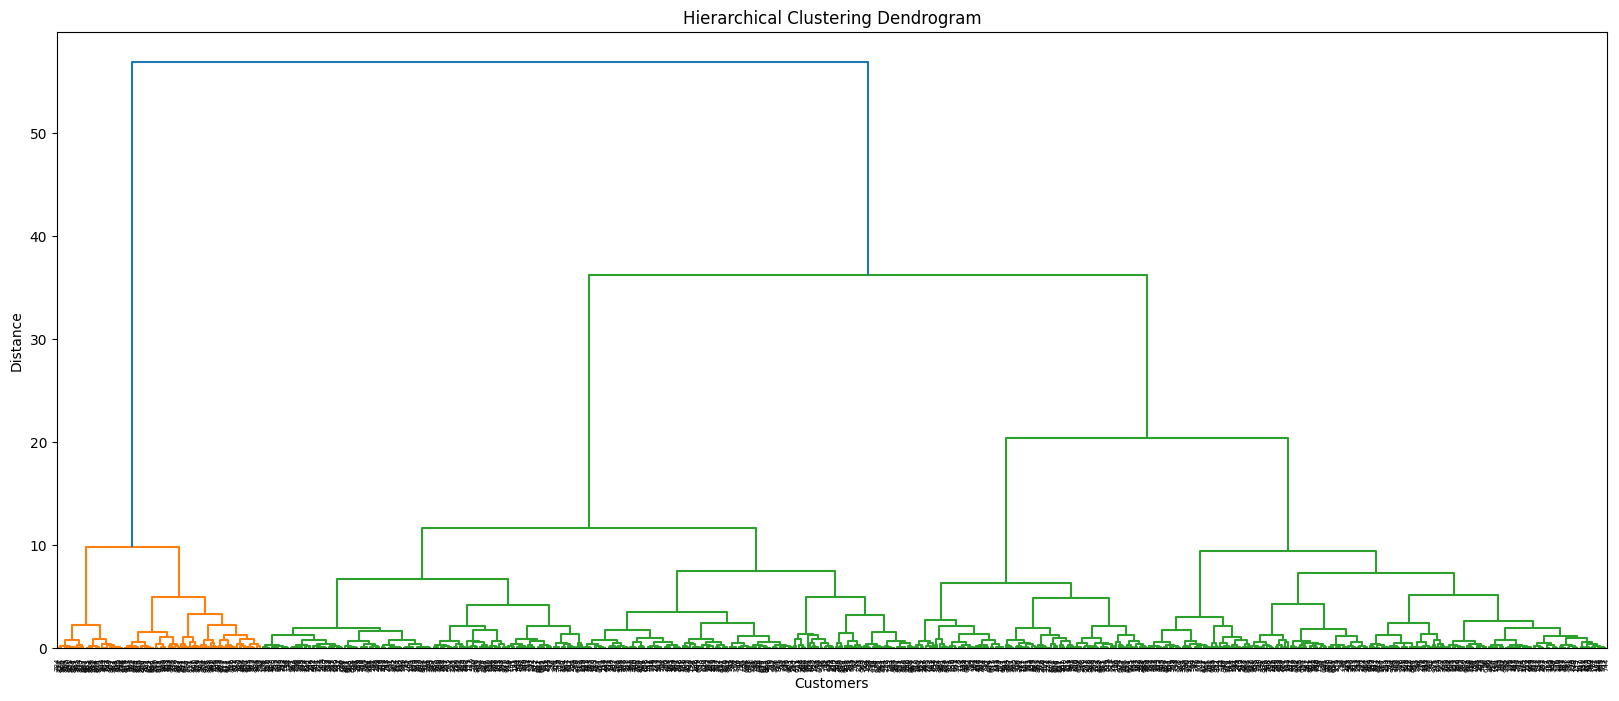

In [ ]:
plt.figure(figsize=(20, 8))

dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [ ]:
silhouette_hierarchical = silhouette_score(
    X_pca,
    hierarchical_labels
)

print(silhouette_hierarchical)

0.5865541790958165


In [ ]:
k_values = range(2, 7)

silhouette_scores = []

for k in k_values:

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    labels = model.fit_predict(X_pca)

    score = silhouette_score(X_pca, labels)

    silhouette_scores.append(score)

In [ ]:
print(silhouette_scores)

[np.float64(0.5865541790958165), np.float64(0.42760763562654536), np.float64(0.3865948035379606), np.float64(0.3311993531091341), np.float64(0.32162858368911934)]


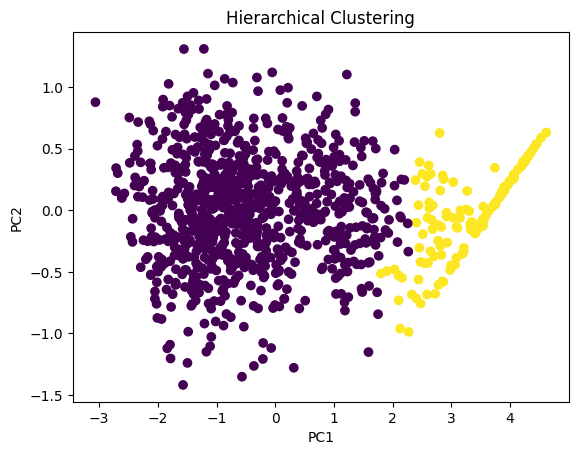

In [ ]:
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=hierarchical_labels
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Hierarchical Clustering')
plt.show()

In [ ]:
df['Hierarchical_Cluster'] = hierarchical_labels

In [ ]:
hierarchical_profile = df.groupby(
    'Hierarchical_Cluster'
)[
    ['Age',
     'Annual Income (k$)',
     'Spending Score (1-100)']
].mean()

print(hierarchical_profile)

                            Age  Annual Income (k$)  Spending Score (1-100)
Hierarchical_Cluster                                                       
0                     34.813364           49.505760               48.406682
1                     65.909091          107.162879                4.962121


In [ ]:
print(cluster_profile)

   Cluster                          Segment        Age  Annual Income (k$)  \
0        0            Young Active Spenders  32.113798           41.480085   
1        1  Affluent Low-Spending Customers  55.023569           94.127946   

   Spending Score (1-100)  
0               53.034139  
1               18.144781  


In [ ]:
hierarchical_counts = df['Hierarchical_Cluster'].value_counts().sort_index()

print(hierarchical_counts)

Hierarchical_Cluster
0    868
1    132
Name: count, dtype: int64


In [ ]:
cluster_counts = df['Cluster'].value_counts().sort_index()

print(cluster_counts)

Cluster
0    703
1    297
Name: count, dtype: int64


In [ ]:
overall_profile = df[
    ['Age',
     'Annual Income (k$)',
     'Spending Score (1-100)']
].mean()

print(overall_profile)

Age                       38.9180
Annual Income (k$)        57.1165
Spending Score (1-100)    42.6720
dtype: float64


In [ ]:
different_assignments = df['Cluster'] != df['Hierarchical_Cluster']

print(different_assignments.sum())

165


In [ ]:
pd.crosstab(
    df['Cluster'],
    df['Hierarchical_Cluster']
)

Hierarchical_Cluster,0,1
Cluster,,
0,703,0
1,165,132


In [ ]:
different_customers = df[
    (df['Cluster'] == 1) &
    (df['Hierarchical_Cluster'] == 0)
]

print(different_customers.shape)

(165, 8)


In [ ]:
different_profile = different_customers[
    ['Age',
     'Annual Income (k$)',
     'Spending Score (1-100)']
].mean()

print(different_profile)

Age                       46.315152
Annual Income (k$)        83.700000
Spending Score (1-100)    28.690909
dtype: float64


DBSCAN

In [ ]:
from sklearn.neighbors import NearestNeighbors
min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_pca)

distances, indices = neighbors.kneighbors(X_pca)

k_distances = distances[:, 4]

k_distances = np.sort(k_distances)
k_distances

array([0.01580466, 0.0169315 , 0.01779527, 0.01882535, 0.01933266,
       0.02156359, 0.02247902, 0.02247902, 0.02366887, 0.02366887,
       0.02366887, 0.02366887, 0.02418786, 0.02534635, 0.02605697,
       0.02789501, 0.02899898, 0.02963737, 0.02963737, 0.03013441,
       0.03073231, 0.03144422, 0.03144422, 0.03144422, 0.033863  ,
       0.033863  , 0.03448158, 0.03493611, 0.0378322 , 0.03801736,
       0.03805563, 0.03805563, 0.03827497, 0.0382862 , 0.0387917 ,
       0.04001193, 0.04046217, 0.04101085, 0.0411629 , 0.04197557,
       0.04197718, 0.04211312, 0.04270146, 0.04294663, 0.04353934,
       0.04450501, 0.04456281, 0.04481757, 0.04495458, 0.04524303,
       0.04526716, 0.04590369, 0.0459202 , 0.04595693, 0.04595693,
       0.04612311, 0.04652544, 0.04733775, 0.04733775, 0.04758186,
       0.04773535, 0.04785232, 0.04785232, 0.04785232, 0.04837572,
       0.04881181, 0.04903221, 0.04908862, 0.04992831, 0.04994416,
       0.05003284, 0.05032628, 0.05032628, 0.05035709, 0.05069

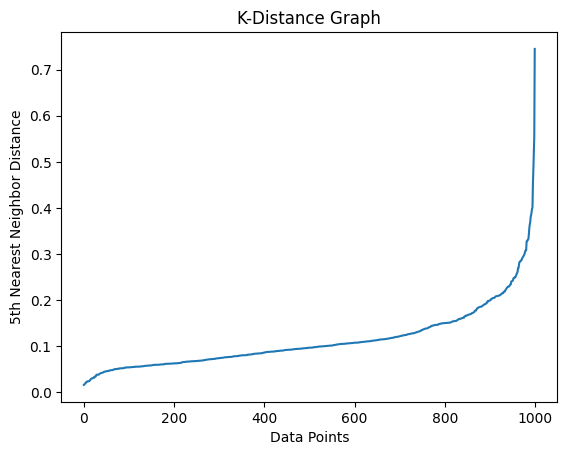

In [ ]:
plt.plot(k_distances)
plt.xlabel("Data Points")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Graph")
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np

eps_values = [0.15, 0.18, 0.20, 0.22, 0.24, 0.26, 0.28, 0.30]

for eps in eps_values:

    labels = DBSCAN(
        eps=eps,
        min_samples=5
    ).fit_predict(X_pca)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    print(
        f"eps={eps:.2f} | "
        f"clusters={n_clusters} | "
        f"noise={n_noise}"
    )

eps=0.15 | clusters=9 | noise=118
eps=0.18 | clusters=6 | noise=71
eps=0.20 | clusters=2 | noise=46
eps=0.22 | clusters=1 | noise=32
eps=0.24 | clusters=1 | noise=26
eps=0.26 | clusters=1 | noise=21
eps=0.28 | clusters=1 | noise=17
eps=0.30 | clusters=1 | noise=10


In [ ]:
dbscan = DBSCAN(
    eps=0.20,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_pca)

In [ ]:
print(np.unique(dbscan_labels))

[-1  0  1]


In [ ]:
dbscan_counts = pd.Series(dbscan_labels).value_counts().sort_index()

print(dbscan_counts)

-1     46
 0    833
 1    121
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import silhouette_score

mask = dbscan_labels != -1

silhouette = silhouette_score(
    X_pca[mask],
    dbscan_labels[mask]
)

print("DBSCAN Silhouette Score:", silhouette)

DBSCAN Silhouette Score: 0.6022407874106598


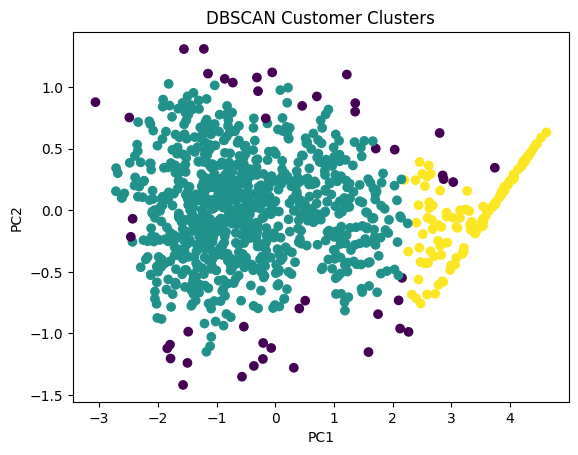

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Customer Clusters")

plt.show()

In [ ]:
df['DBSCAN_Cluster'] = dbscan_labels

dbscan_profile = df.groupby('DBSCAN_Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean()

print(dbscan_profile)

                      Age  Annual Income (k$)  Spending Score (1-100)
DBSCAN_Cluster                                                       
-1              39.434783           60.528261               39.260870
 0              34.845138           49.498679               48.397359
 1              66.760331          108.262810                4.553719


In [ ]:
print(df[['Age',
          'Annual Income (k$)',
          'Spending Score (1-100)']].describe())

               Age  Annual Income (k$)  Spending Score (1-100)
count  1000.000000         1000.000000             1000.000000
mean     38.918000           57.116500               42.672000
std      13.361505           28.575769               20.043956
min      18.000000           15.000000                1.000000
25%      30.000000           35.075000               31.750000
50%      36.000000           49.000000               47.000000
75%      44.000000           79.325000               57.000000
max      80.000000          144.100000               92.000000


In [ ]:
print("Age <= 40:",
      (df['Age'] <= 40).sum())

print("Age > 40:",
      (df['Age'] > 40).sum())

Age <= 40: 669
Age > 40: 331


In [ ]:
age_groups = pd.cut(
    df['Age'],
    bins=[0, 30, 40, 50, 60, 100],
    labels=['18-30', '31-40', '41-50', '51-60', '60+']
)

print(age_groups.value_counts().sort_index())

Age
18-30    263
31-40    406
41-50    179
51-60     56
60+       96
Name: count, dtype: int64


In [ ]:
young_moderate = df[
    (df['Age'] <= 40) &
    (df['Annual Income (k$)'] <= 60) &
    (df['Spending Score (1-100)'] >= 40)
]

print("Customers matching this profile:",
      len(young_moderate))

Customers matching this profile: 556


In [ ]:
affluent_low_spending = df[
    (df['Age'] >= 60) &
    (df['Annual Income (k$)'] >= 90) &
    (df['Spending Score (1-100)'] <= 15)
]

print("Customers matching this profile:",
      len(affluent_low_spending))

Customers matching this profile: 92


In [ ]:
overall_profile = df[
    ['Age',
     'Annual Income (k$)',
     'Spending Score (1-100)']
].mean()

print("Overall Dataset:")
print(overall_profile)

print("\nDBSCAN Profile:")
print(dbscan_profile)

Overall Dataset:
Age                       38.9180
Annual Income (k$)        57.1165
Spending Score (1-100)    42.6720
dtype: float64

DBSCAN Profile:
                      Age  Annual Income (k$)  Spending Score (1-100)
DBSCAN_Cluster                                                       
-1              39.434783           60.528261               39.260870
 0              34.845138           49.498679               48.397359
 1              66.760331          108.262810                4.553719


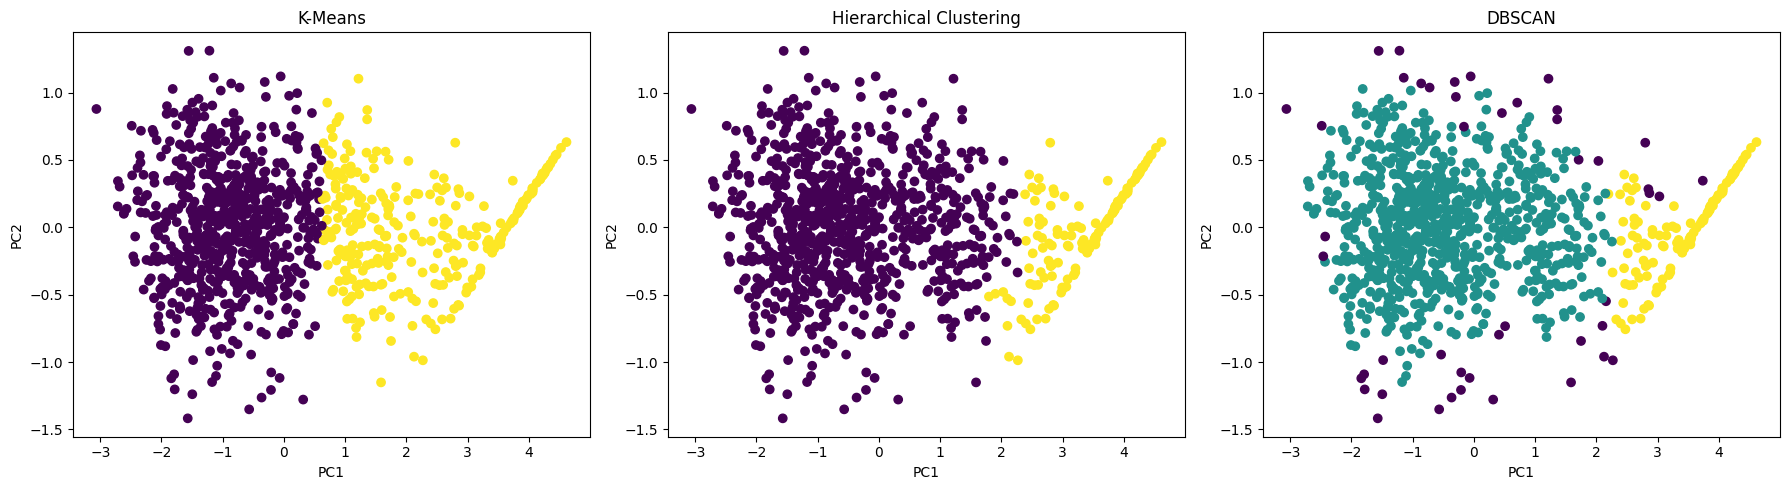

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels
)
axes[0].set_title("K-Means")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# Hierarchical
axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=hierarchical_labels
)
axes[1].set_title("Hierarchical Clustering")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

# DBSCAN
axes[2].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels
)
axes[2].set_title("DBSCAN")
axes[2].set_xlabel("PC1")
axes[2].set_ylabel("PC2")

plt.tight_layout()
plt.show()

In [ ]:
# K-Means profile
kmeans_profile = df.groupby('Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean().reset_index()

kmeans_profile['Algorithm'] = 'K-Means'

 #Hierarchical profile
hierarchical_profile = df.groupby('Hierarchical_Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean().reset_index()

hierarchical_profile['Algorithm'] = 'Hierarchical'
hierarchical_profile = hierarchical_profile.rename(
    columns={'Hierarchical_Cluster': 'Cluster'}
)

# DBSCAN profile
dbscan_profile = df.groupby('DBSCAN_Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean().reset_index()

dbscan_profile['Algorithm'] = 'DBSCAN'
dbscan_profile = dbscan_profile.rename(
    columns={'DBSCAN_Cluster': 'Cluster'}
)


In [ ]:
print(kmeans_profile)

   Cluster        Age  Annual Income (k$)  Spending Score (1-100) Algorithm
0        0  32.113798           41.480085               53.034139   K-Means
1        1  55.023569           94.127946               18.144781   K-Means


In [ ]:
print(hierarchical_profile)

   Cluster        Age  Annual Income (k$)  Spending Score (1-100)  \
0        0  34.813364           49.505760               48.406682   
1        1  65.909091          107.162879                4.962121   

      Algorithm  
0  Hierarchical  
1  Hierarchical  


In [ ]:
print(dbscan_profile)

   Cluster        Age  Annual Income (k$)  Spending Score (1-100) Algorithm
0       -1  39.434783           60.528261               39.260870    DBSCAN
1        0  34.845138           49.498679               48.397359    DBSCAN
2        1  66.760331          108.262810                4.553719    DBSCAN


In [ ]:
all_profiles = pd.concat(
    [kmeans_profile,
     hierarchical_profile,
     dbscan_profile],
    ignore_index=True
)

print(all_profiles)

   Cluster        Age  Annual Income (k$)  Spending Score (1-100)  \
0        0  32.113798           41.480085               53.034139   
1        1  55.023569           94.127946               18.144781   
2        0  34.813364           49.505760               48.406682   
3        1  65.909091          107.162879                4.962121   
4       -1  39.434783           60.528261               39.260870   
5        0  34.845138           49.498679               48.397359   
6        1  66.760331          108.262810                4.553719   

      Algorithm  
0       K-Means  
1       K-Means  
2  Hierarchical  
3  Hierarchical  
4        DBSCAN  
5        DBSCAN  
6        DBSCAN  


In [ ]:
all_profiles['Segment'] = ''

all_profiles.loc[
    (all_profiles['Cluster'] == 0) &
    (all_profiles['Algorithm'] != 'DBSCAN'),
    'Segment'
] = 'Young Moderate-Income Active Spenders'

all_profiles.loc[
    (all_profiles['Cluster'] == 1) &
    (all_profiles['Algorithm'] != 'DBSCAN'),
    'Segment'
] = 'Older Affluent Low-Spending Customers'

all_profiles.loc[
    (all_profiles['Algorithm'] == 'DBSCAN') &
    (all_profiles['Cluster'] == -1),
    'Segment'
] = 'Noise / Unusual Customers'

all_profiles.loc[
    (all_profiles['Algorithm'] == 'DBSCAN') &
    (all_profiles['Cluster'] == 0),
    'Segment'
] = 'Young Moderate-Income Active Spenders'

all_profiles.loc[
    (all_profiles['Algorithm'] == 'DBSCAN') &
    (all_profiles['Cluster'] == 1),
    'Segment'
] = 'Older Affluent Low-Spending Customers'

print(all_profiles)

   Cluster        Age  Annual Income (k$)  Spending Score (1-100)  \
0        0  32.113798           41.480085               53.034139   
1        1  55.023569           94.127946               18.144781   
2        0  34.813364           49.505760               48.406682   
3        1  65.909091          107.162879                4.962121   
4       -1  39.434783           60.528261               39.260870   
5        0  34.845138           49.498679               48.397359   
6        1  66.760331          108.262810                4.553719   

      Algorithm                                Segment  
0       K-Means  Young Moderate-Income Active Spenders  
1       K-Means  Older Affluent Low-Spending Customers  
2  Hierarchical  Young Moderate-Income Active Spenders  
3  Hierarchical  Older Affluent Low-Spending Customers  
4        DBSCAN              Noise / Unusual Customers  
5        DBSCAN  Young Moderate-Income Active Spenders  
6        DBSCAN  Older Affluent Low-Spending Cus

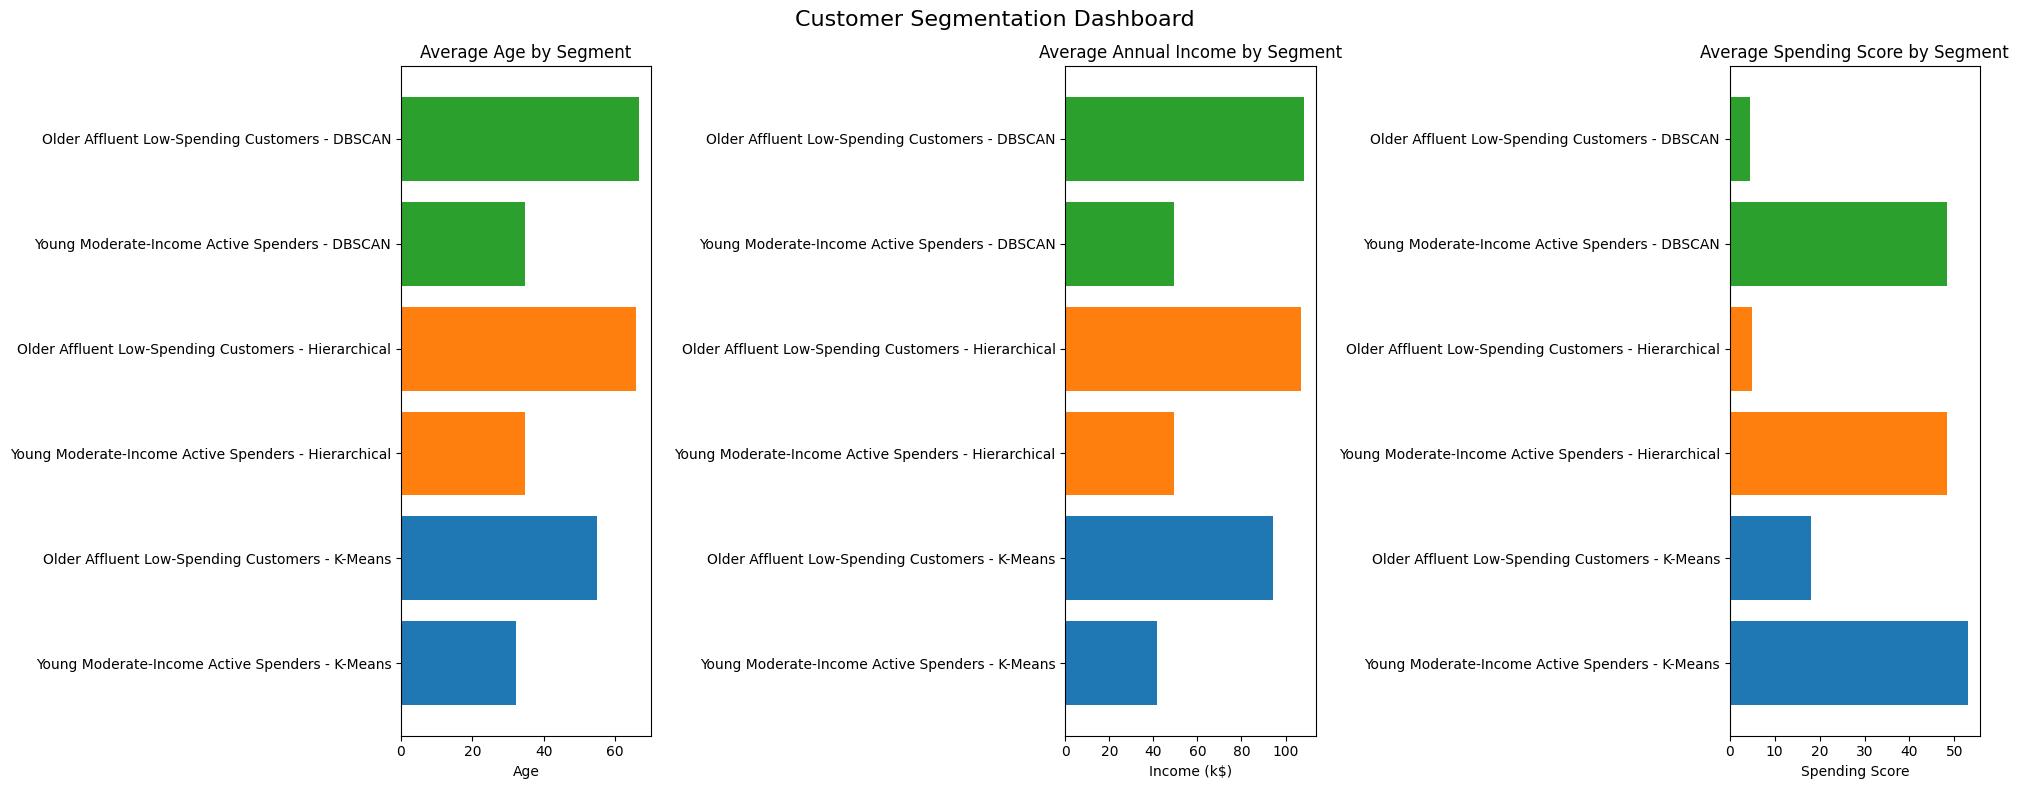

In [ ]:
import matplotlib.pyplot as plt

# Remove DBSCAN noise from segment comparison
dashboard_data = all_profiles[
    all_profiles['Segment'] != 'Noise / Unusual Customers'
]

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# -------------------------
# Average Age
# -------------------------
for algorithm in dashboard_data['Algorithm'].unique():

    data = dashboard_data[
        dashboard_data['Algorithm'] == algorithm
    ]

    labels = data['Segment'] + ' - ' + data['Algorithm']

    axes[0].barh(
        labels,
        data['Age']
    )

axes[0].set_title('Average Age by Segment')
axes[0].set_xlabel('Age')

# -------------------------
# Average Annual Income
# -------------------------
for algorithm in dashboard_data['Algorithm'].unique():

    data = dashboard_data[
        dashboard_data['Algorithm'] == algorithm
    ]

    labels = data['Segment'] + ' - ' + data['Algorithm']

    axes[1].barh(
        labels,
        data['Annual Income (k$)']
    )

axes[1].set_title('Average Annual Income by Segment')
axes[1].set_xlabel('Income (k$)')

# -------------------------
# Average Spending Score
# -------------------------
for algorithm in dashboard_data['Algorithm'].unique():

    data = dashboard_data[
        dashboard_data['Algorithm'] == algorithm
    ]

    labels = data['Segment'] + ' - ' + data['Algorithm']

    axes[2].barh(
        labels,
        data['Spending Score (1-100)']
    )

axes[2].set_title('Average Spending Score by Segment')
axes[2].set_xlabel('Spending Score')

# Main title
plt.suptitle(
    'Customer Segmentation Dashboard',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
all_profiles.to_csv(
    "customer_segment_profiles.csv",
    index=False
)

print("CSV created successfully!")

CSV created successfully!


In [ ]:
import os

print(os.path.exists("customer_segment_profiles.csv"))

True


In [ ]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 73.4 MB/s eta 0:00:00


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# PAGE SETTINGS
# --------------------------------------------------

st.set_page_config(
    page_title="Customer Segmentation Dashboard",
    page_icon="📊",
    layout="wide"
)

# --------------------------------------------------
# TITLE
# --------------------------------------------------

st.title("📊 Customer Segmentation Dashboard")

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------

df = pd.read_csv("customer_segment_profiles.csv")

st.write(
    "**Algorithms Used:** "
    "K-Means, Hierarchical Clustering, DBSCAN"
)

st.write(
    "**Customer Characteristics:** "
    "Age, Annual Income, Spending Score"
)


# ==================================================
# CREATE GRAPH LABELS
# ==================================================

labels = (
    df["Algorithm"]
    + " - "
    + df["Segment"]
)


# ==================================================
# GRAPH 1 — AVERAGE AGE
# ==================================================

st.header("📊 Average Age by Segment")

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    labels,
    df["Age"]
)

ax.set_xlabel("Average Age")
ax.set_ylabel("Customer Segment")
ax.set_title("Average Age by Segment")

plt.tight_layout()

st.pyplot(fig)

plt.close(fig)


# ==================================================
# GRAPH 2 — AVERAGE ANNUAL INCOME
# ==================================================

st.header("💰 Average Annual Income by Segment")

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    labels,
    df["Annual Income (k$)"]
)

ax.set_xlabel("Average Annual Income (k$)")
ax.set_ylabel("Customer Segment")
ax.set_title("Average Annual Income by Segment")

plt.tight_layout()

st.pyplot(fig)

plt.close(fig)


# ==================================================
# GRAPH 3 — AVERAGE SPENDING SCORE
# ==================================================

st.header("🛍️ Average Spending Score by Segment")

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    labels,
    df["Spending Score (1-100)"]
)

ax.set_xlabel("Spending Score")
ax.set_ylabel("Customer Segment")
ax.set_title("Average Spending Score by Segment")

plt.tight_layout()

st.pyplot(fig)

plt.close(fig)

Writing app.py


In [ ]:
!pkill -f streamlit
!pkill -f localtunnel

In [ ]:
!streamlit run app.py --server.address 0.0.0.0 --server.port 8501 &>/content/logs.txt &

In [ ]:
!npm install -g localtunnel -q

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹
added 22 packages in 2s
⠹
⠹3 packages are looking for funding
⠹  run `npm fund` for details
⠹

In [ ]:
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧your url is: https://slimy-baboons-lay.loca.lt
^C


In [ ]:
!ls /content

app.py	customer_segment_profiles.csv  logs.txt  sample_data


In [ ]:
import pandas as pd

df = pd.read_csv("customer_segment_profiles.csv")

print(df.columns.tolist())

df.head()

['Cluster', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Algorithm', 'Segment']


,Cluster,Age,Annual Income (k$),Spending Score (1-100),Algorithm,Segment
0,0,32.113798,41.480085,53.034139,K-Means,Young Moderate-Income Active Spenders
1,1,55.023569,94.127946,18.144781,K-Means,Older Affluent Low-Spending Customers
2,0,34.813364,49.505760,48.406682,Hierarchical,Young Moderate-Income Active Spenders
3,1,65.909091,107.162879,4.962121,Hierarchical,Older Affluent Low-Spending Customers
4,-1,39.434783,60.528261,39.260870,DBSCAN,Noise / Unusual Customers
